# Cluster Analysis of Vessel Trajectories

This notebook analyzes the output of the self-supervised BYOL model and HDBSCAN clustering pipeline.

Pipeline:

1. Raw AIS trajectories
2. Trajectory compression (50 m)
3. Rasterization into 4-channel images
4. BYOL self-supervised training
5. Embedding extraction (32 dimensions)
6. HDBSCAN clustering
7. Cluster analysis and visualization

Files used:

- HDF5 dataset:
  - `DP_50_Compressed_allaData_3ports_to_use_in_github.hdf5`

- Trained model:
  - `trained_model_20260605_0057.pt`

- Exported embeddings:
  - `exported/trained_model_20260605_0057.csv`

Goals:

- Inspect cluster sizes
- Visualize representative trajectories
- Investigate HDBSCAN noise points (-1)
- Compare trajectory patterns between clusters
- Understand what movement behaviors were learned by the model

## Load Cluster Results

Load the exported embeddings and cluster labels generated by:

`run_multilayer_inference.py`

The CSV contains:

- cluster label
- trajectory filename
- 32-dimensional embedding vector

In [3]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np

## Load Cluster Results

In [9]:
df = pd.read_csv(
    "../exported/trained_model_20260429_0158_true.csv",
    sep=";"
)

df.head()

,Unnamed: 0,cluster,filename,emb_dim_0,emb_dim_1,emb_dim_2,emb_dim_3,emb_dim_4,emb_dim_5,emb_dim_6,...,emb_dim_22,emb_dim_23,emb_dim_24,emb_dim_25,emb_dim_26,emb_dim_27,emb_dim_28,emb_dim_29,emb_dim_30,emb_dim_31
0,0,3,traj_0_imo_9237747,3.620277,-1.485469,-3.233547,4.333286,2.271840,3.189894,-2.653964,...,-6.776060,4.044666,-9.274502,4.739540,-4.212634,-3.621389,4.238895,-2.058248,5.640870,3.089392
1,1,2,traj_100009_imo_9232840,-0.333661,0.267685,0.065969,-0.419054,-0.253187,0.232060,-0.105459,...,0.303373,-0.101722,0.301321,-0.406600,0.374966,0.560333,-0.447687,0.185532,-0.084016,0.208224
2,2,3,traj_100010_imo_9232840,-0.680662,0.603781,-1.409193,0.700086,0.472869,1.553815,-0.513849,...,-0.834293,1.902501,-3.087762,1.342460,-0.893559,-0.418565,0.630995,-0.859955,1.182255,1.233327
3,3,2,traj_100011_imo_9232840,-0.294926,0.245408,0.070483,-0.328663,-0.132979,0.223749,-0.117194,...,0.244118,-0.194597,0.272377,-0.289679,0.248540,0.446385,-0.382958,0.202731,-0.046512,0.143609
4,4,2,traj_100012_imo_9232840,-0.320003,0.256973,0.069508,-0.397715,-0.201624,0.249159,-0.150298,...,0.285457,-0.100809,0.267103,-0.363176,0.335193,0.534186,-0.431524,0.175059,-0.098342,0.210582


## Cluster Size Distribution

Visualize the number of trajectories assigned to each HDBSCAN cluster.

Cluster `-1` corresponds to trajectories classified as noise/outliers.

In [10]:
counts = (
    df["cluster"]
    .value_counts()
    .sort_index()
)

print(counts)

cluster
-1    14970
 0      199
 1     1223
 2    63809
 3    11230
Name: count, dtype: int64


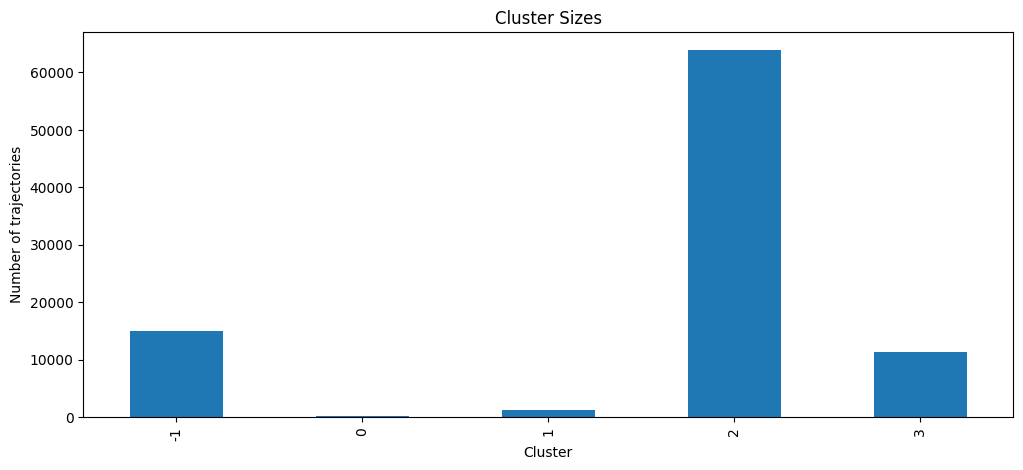

In [11]:
plt.figure(figsize=(12,5))

counts.plot(kind="bar")

plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of trajectories")

plt.show()

## Load HDF5 Dataset

In [13]:
HDF5_FILE = (
    "../DP_50_Compressed_allaData_3ports_to_use_in_github.hdf5"
)

f = h5py.File(
    HDF5_FILE,
    "r"
)

print("Datasets:", len(f))

Datasets: 91431


## Visualize Sample Trajectories From Each Cluster

In [14]:
cluster_ids = sorted(
    df["cluster"].unique()
)

print(cluster_ids)

[np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


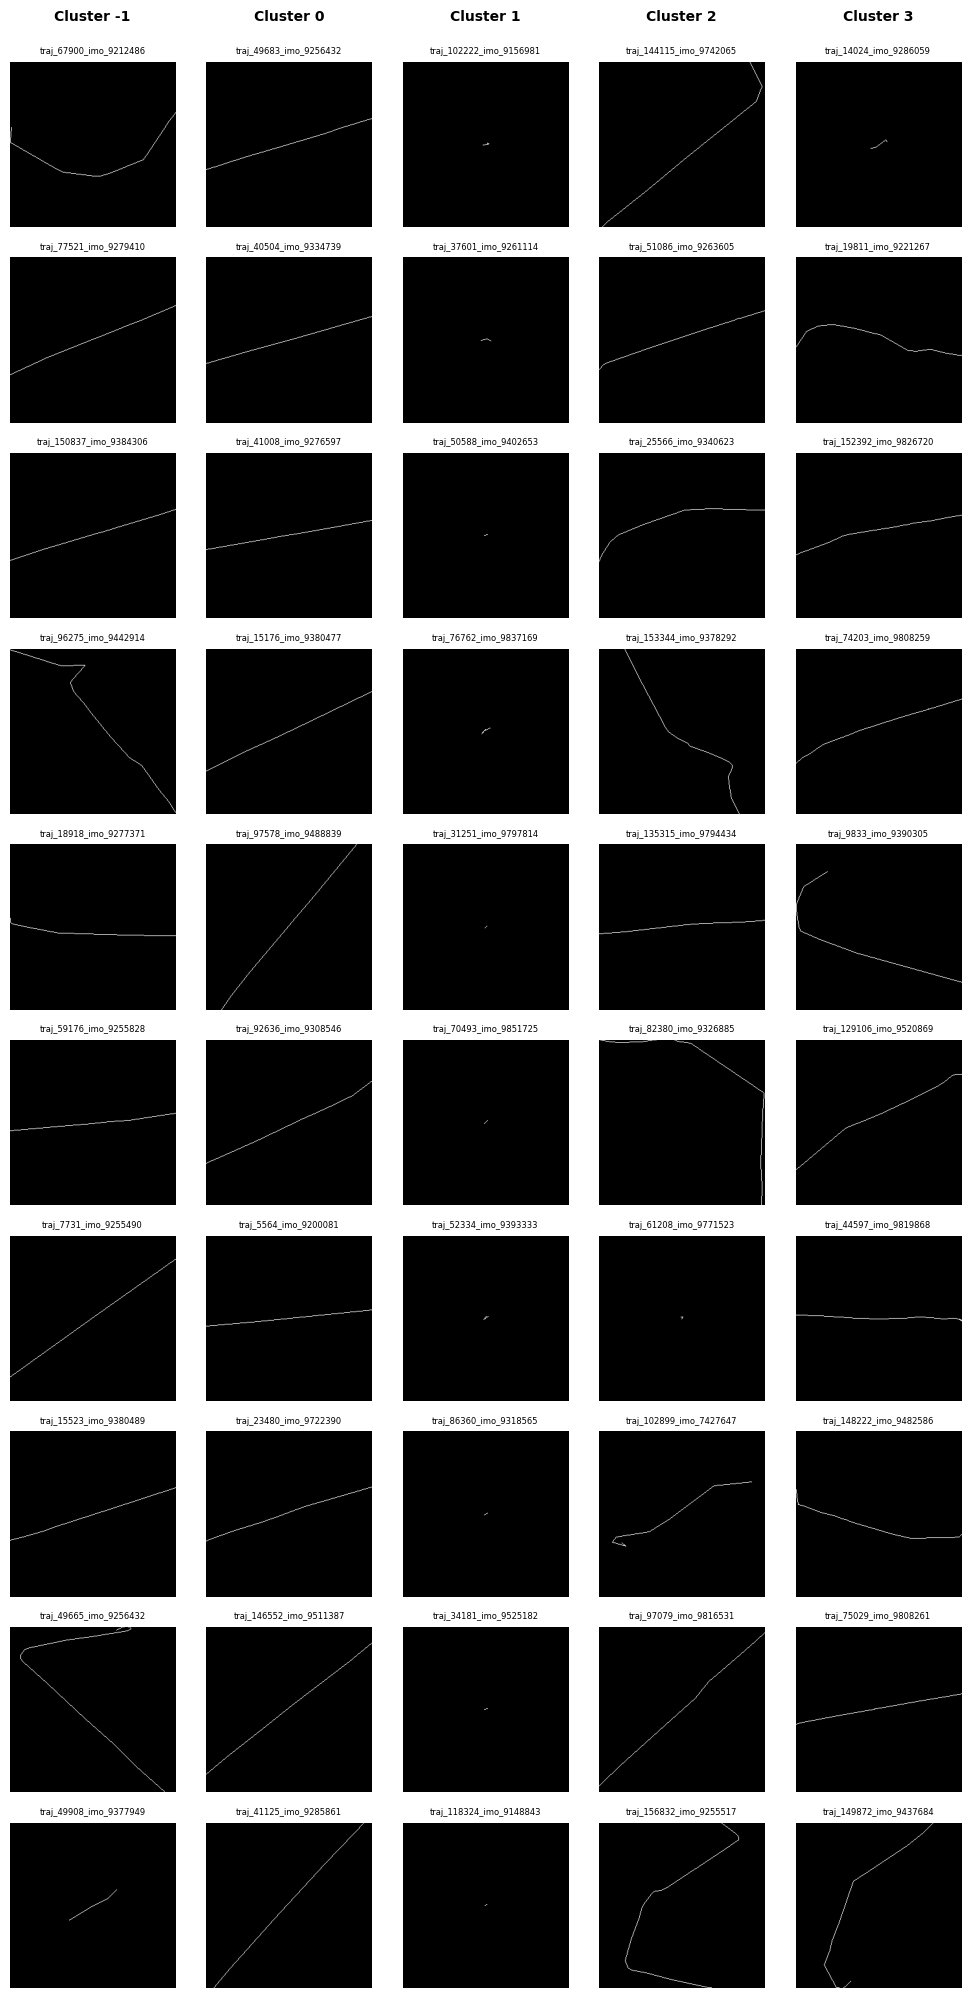

In [17]:
def show_clusters_grid(cluster_ids, n=5):
    num_clusters = len(cluster_ids)

    fig, axes = plt.subplots(n, num_clusters, figsize=(2*num_clusters, 2*n))
    for col, cluster_id in enumerate(cluster_ids):
        samples = df[df["cluster"] == cluster_id].sample(n, replace=True)
    
        for row, (_, sample) in enumerate(samples.iterrows()):
            img = f[sample["filename"]][:]
    
            ax = axes[row, col] if n > 1 else axes[col]
            ax.imshow(img[0], cmap="gray")
            ax.axis("off")
    
            # filename ABOVE each image
            ax.set_title(sample["filename"], fontsize=6)
    
            # cluster label ABOVE column (only once)
            if row == 0:
                ax.text(
                    0.5, 1.25, f"Cluster {cluster_id}",
                    transform=ax.transAxes,
                    ha="center",
                    fontsize=10,
                    fontweight="bold"
                )
    

    plt.tight_layout()
    plt.show()
show_clusters_grid(cluster_ids, n=10)

/data/users/omarala/miniforge3/envs/exjobb_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


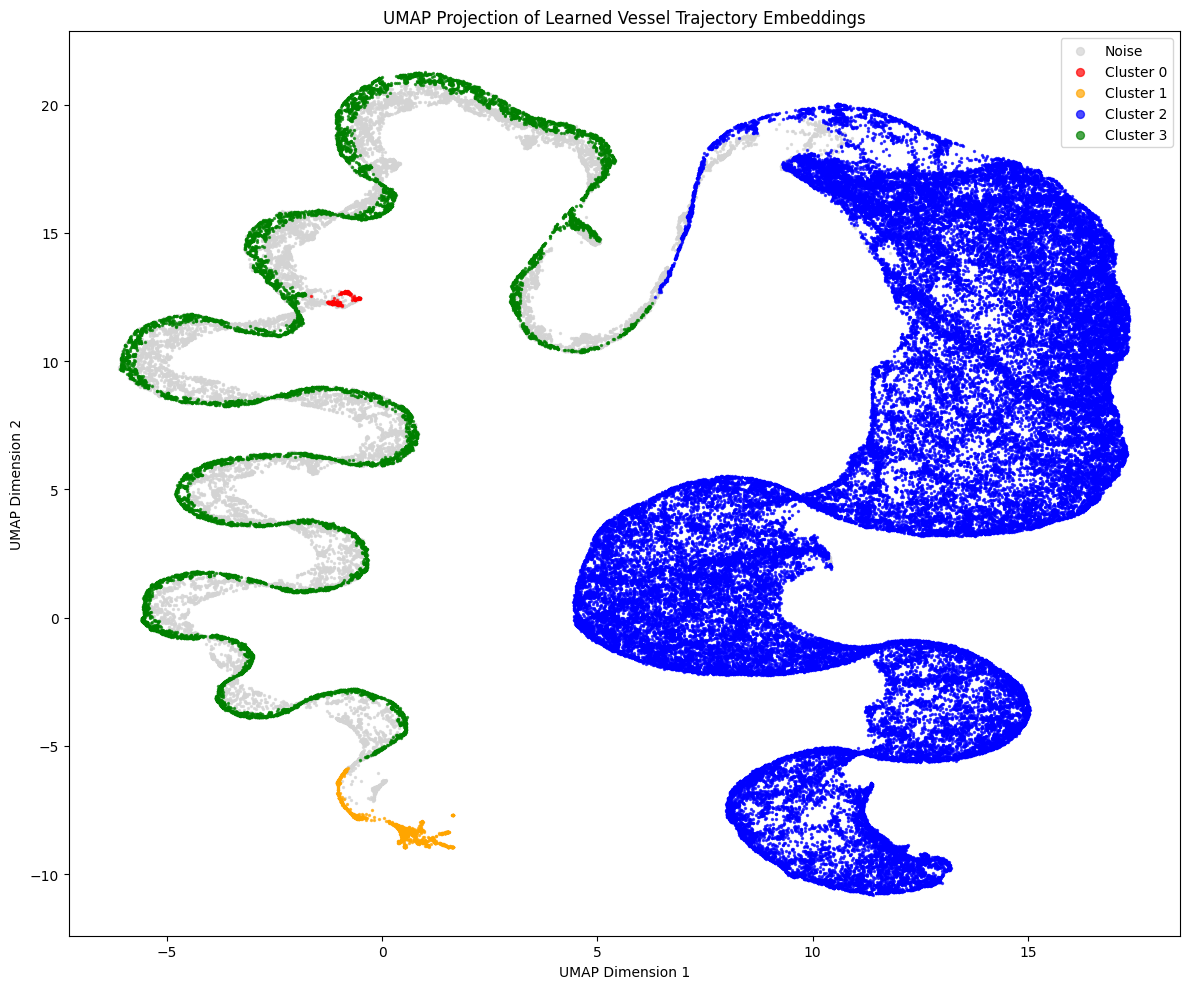

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap

df = pd.read_csv(
    "../exported/trained_model_20260429_0158_true.csv",
    sep=";"
)
embedding_cols = [c for c in df.columns if c.startswith("emb_dim_")]

X = df[embedding_cols].values
clusters = df["cluster"].values

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding_2d = reducer.fit_transform(X)

# -----------------------------
# COLORS
# -----------------------------

colors = {
    -1: "lightgray",
    0: "red",
    1: "orange",
    2: "blue",
    3: "green"
}

labels = {
    -1: "Noise",
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3"
}

plt.figure(figsize=(12,10))

for cluster_id in sorted(np.unique(clusters)):
    mask = clusters == cluster_id

    plt.scatter(
        embedding_2d[mask,0],
        embedding_2d[mask,1],
        s=2,
        alpha=0.7,
        color=colors[cluster_id],
        label=labels[cluster_id]
    )

plt.title("UMAP Projection of Learned Vessel Trajectory Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.legend(markerscale=4)

plt.tight_layout()

plt.savefig(
    "umap_hdbscan_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

cluster
-1    14970
 0      199
 1     1223
 2    63809
 3    11230
Name: count, dtype: int64


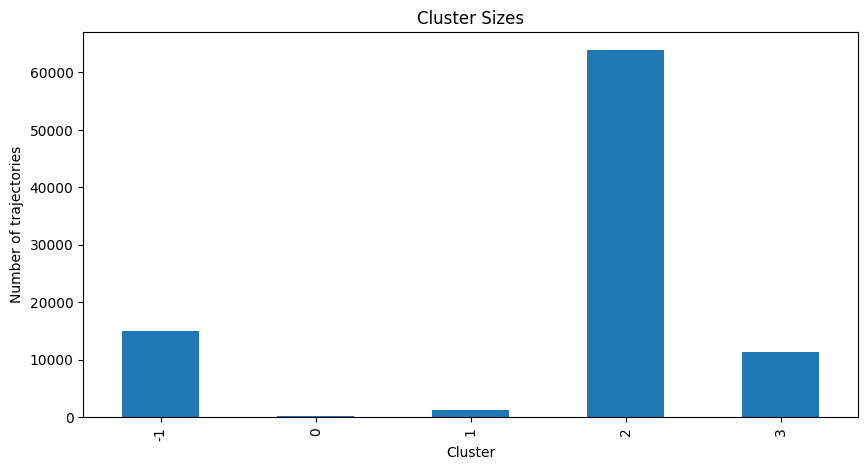

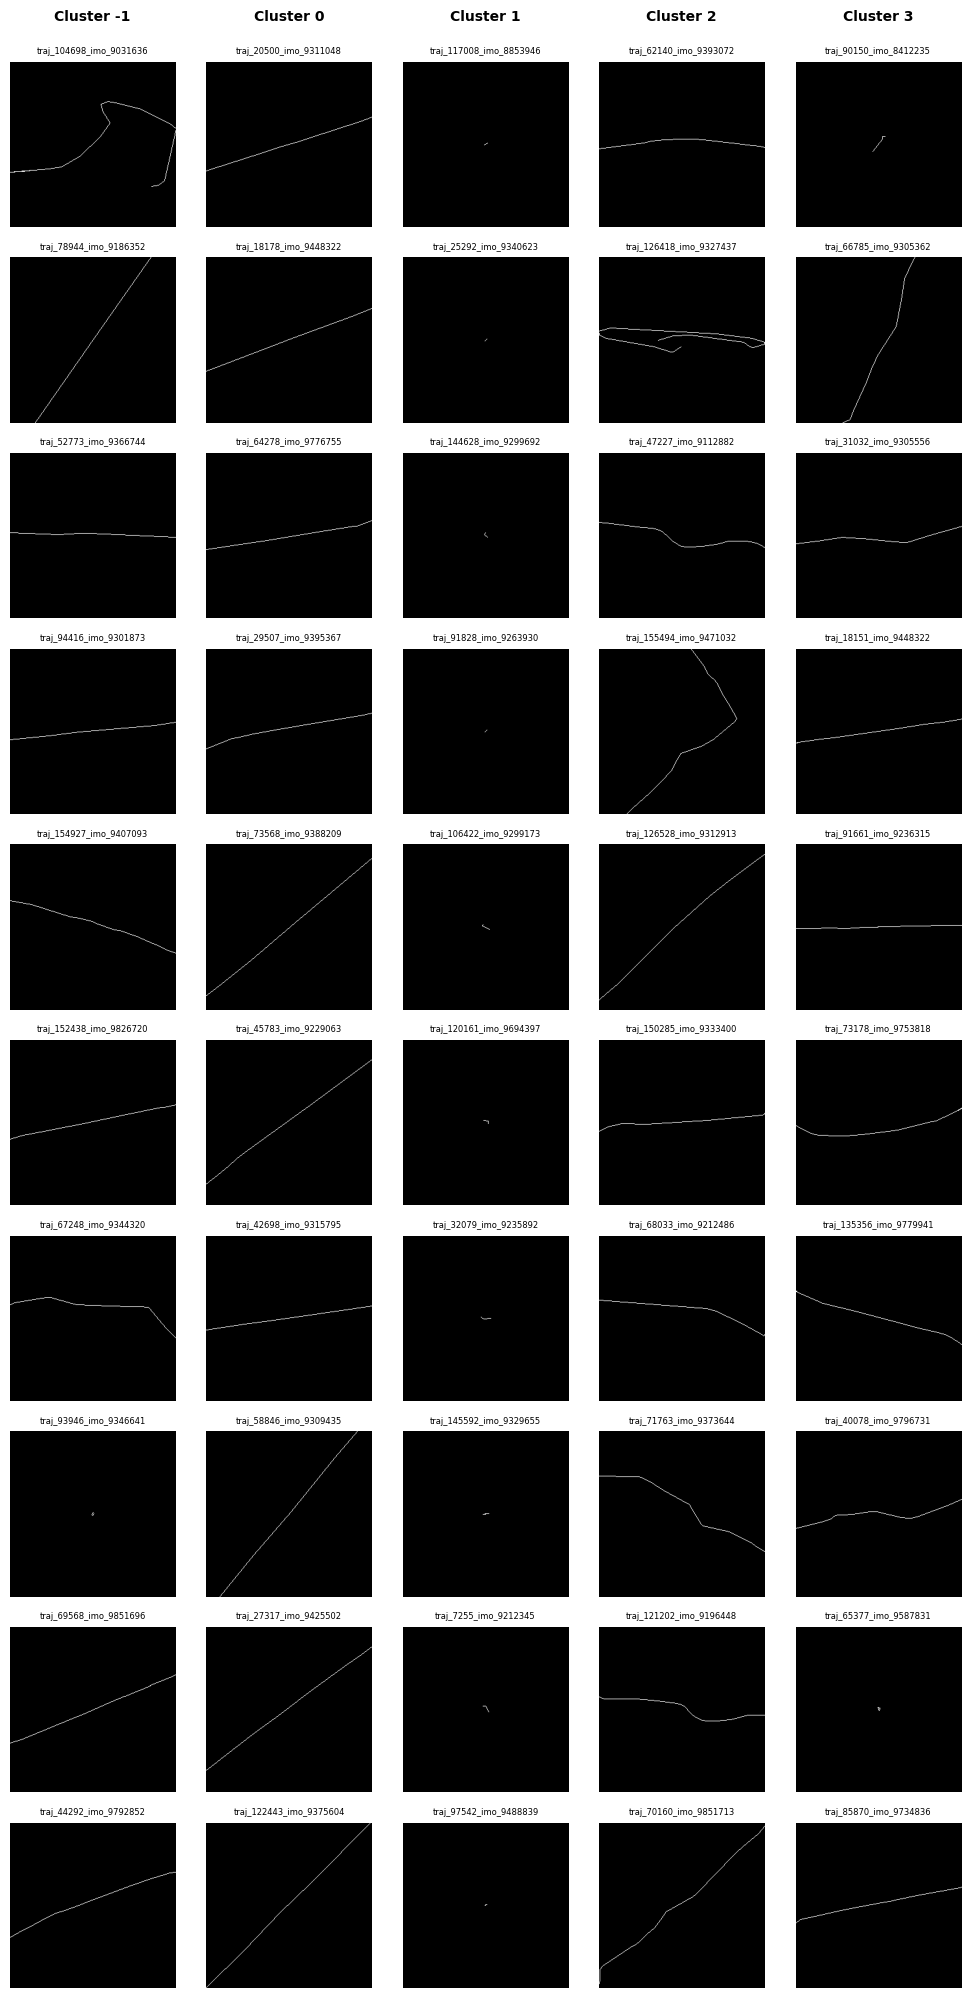

In [8]:
# remove
import pandas as pd

import h5py
import matplotlib.pyplot as plt
df = pd.read_csv("../exported/trained_model_20260429_0158_true.csv", sep=";")

counts = df["cluster"].value_counts().sort_index()

print(counts)


counts.plot(kind="bar", figsize=(10,5))
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of trajectories")
plt.show()



hdf5_file = "../DP_50_Compressed_allaData_3ports_to_use_in_github.hdf5"
f = h5py.File(hdf5_file, "r")

cluster_ids = sorted(df["cluster"].unique())
def show_clusters_grid(cluster_ids, n=5):
    num_clusters = len(cluster_ids)

    fig, axes = plt.subplots(n, num_clusters, figsize=(2*num_clusters, 2*n))
    for col, cluster_id in enumerate(cluster_ids):
        samples = df[df["cluster"] == cluster_id].sample(n, replace=True)
    
        for row, (_, sample) in enumerate(samples.iterrows()):
            img = f[sample["filename"]][:]
    
            ax = axes[row, col] if n > 1 else axes[col]
            ax.imshow(img[0], cmap="gray")
            ax.axis("off")
    
            # filename ABOVE each image
            ax.set_title(sample["filename"], fontsize=6)
    
            # cluster label ABOVE column (only once)
            if row == 0:
                ax.text(
                    0.5, 1.25, f"Cluster {cluster_id}",
                    transform=ax.transAxes,
                    ha="center",
                    fontsize=10,
                    fontweight="bold"
                )
    

    plt.tight_layout()
    plt.show()
show_clusters_grid(cluster_ids, n=10)